#  Student Productivity Classification — XGBoost

**Dataset:** `ultimate_student_productivity_dataset_5000.csv`  
**Task:** Binary Classification — **Tinggi vs Rendah Produktivitas**  
**Model:** XGBoost Classifier

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../ultimate_student_productivity_dataset_5000.csv')
print(f'Shape: {df.shape}')
df.info()

Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  int

In [3]:
print(df.describe())

        student_id          age  study_hours  self_study_hours  \
count  5000.000000  5000.000000  5000.000000       5000.000000   
mean   2500.500000    20.520400     4.539594          2.478734   
std    1443.520003     2.870406     1.821665          1.177990   
min       1.000000    16.000000     0.000000          0.000000   
25%    1250.750000    18.000000     3.250000          1.660000   
50%    2500.500000    20.000000     4.530000          2.480000   
75%    3750.250000    23.000000     5.760000          3.290000   
max    5000.000000    25.000000    11.840000          7.410000   

       online_classes_hours  social_media_hours  gaming_hours  sleep_hours  \
count           5000.000000         5000.000000   5000.000000  5000.000000   
mean               2.011984            2.998086      1.564514     7.016492   
std                0.983906            1.467949      1.110807     1.163692   
min                0.000000            0.000000      0.000000     4.000000   
25%            

---
## 2.  Dataset Bisa Digunakan Untuk Apa

In [4]:
median_score = df['productivity_score'].median()
df['high_productivity'] = (df['productivity_score'] >= median_score).astype(int)
print(f'Median score: {median_score:.2f}')
print(df['high_productivity'].value_counts())

Median score: 36.86
high_productivity
1    2501
0    2499
Name: count, dtype: int64


In [5]:
target = 'high_productivity'
drop_cols = ['student_id', 'productivity_score', 'exam_score']
df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target]); y = df_proc[target]
neg, pos = (y == 0).sum(), (y == 1).sum()
scale = neg / pos
print(f'Class imbalance → neg={neg}, pos={pos}, scale_pos_weight={scale:.2f}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Class imbalance → neg=2499, pos=2501, scale_pos_weight=1.00
Train: (4000, 18), Test: (1000, 18)


---
## 3.  XGBoost untuk Classification

XGBoost menggunakan **gradient boosting** dengan regularisasi:

$$\mathcal{L}^{(t)} = \sum_i l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

**Perbedaan dengan Random Forest:**

| Aspek | Random Forest | XGBoost |
|-------|---------------|--------|
| Strategi | Bagging | Boosting |
| Pohon | Independen | Sequential/residual |
| Kecepatan | Lebih lambat (paralel) | Lebih cepat |
| Regularisasi | Kurang | L1 & L2 built-in |

In [ ]:
model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale, eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)
print('Training ')

Training 


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Penjelasan |
|-----------|------------|
| `n_estimators` | Jumlah boosting rounds |
| `learning_rate` | Shrinkage per step (η) |
| `max_depth` | 3–8 direkomendasikan |
| `scale_pos_weight` | Ratio neg/pos untuk imbalanced |
| `subsample` | Fraction of rows per tree |
| `colsample_bytree` | Fraction of cols per tree |
| `reg_alpha` | L1 regularization |
| `reg_lambda` | L2 regularization |

---
## 5.  Evaluasi Yang Dipakai

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Rendah','Tinggi']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

      Rendah       0.90      0.92      0.91       500
      Tinggi       0.92      0.90      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

ROC-AUC: 0.9748


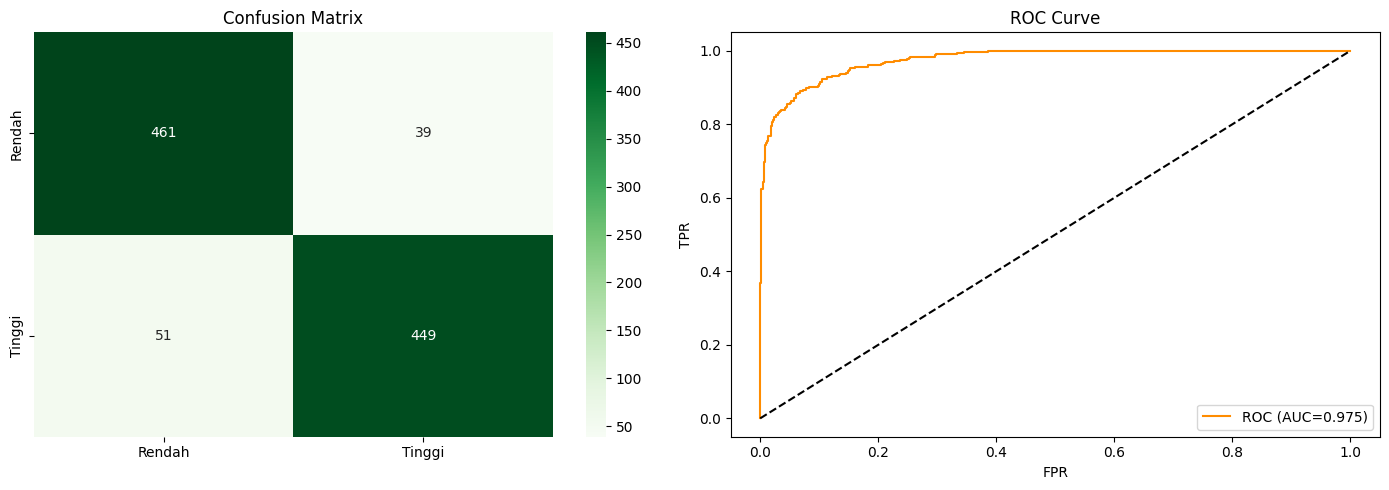

In [8]:
from xgboost import plot_importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Rendah','Tinggi'], yticklabels=['Rendah','Tinggi'])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})', color='darkorange')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
plt.tight_layout(); plt.show()

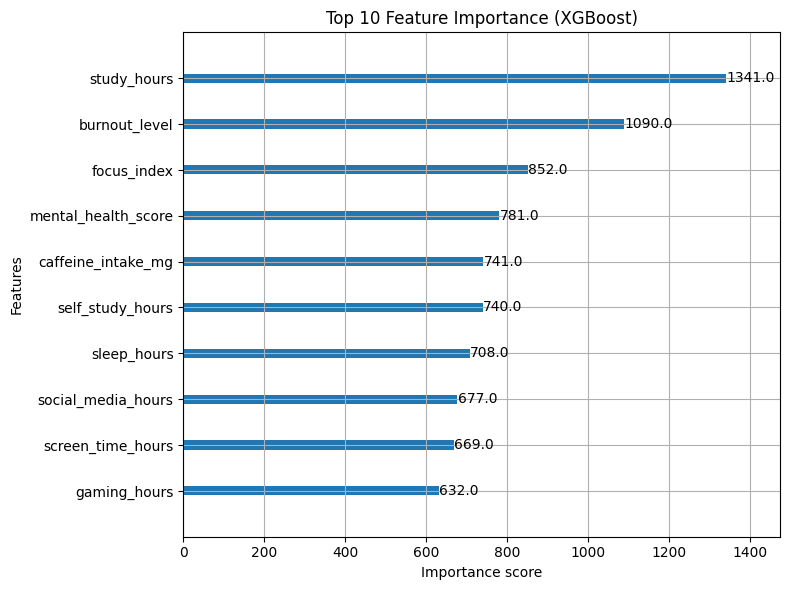

In [9]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
fig, ax = plt.subplots(figsize=(8,6))
plot_importance(model, ax=ax, max_num_features=10, title='Top 10 Feature Importance (XGBoost)')
plt.tight_layout(); plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

**Benchmark untuk classification masalah ini:**

| Metrik | Cukup | Baik | Sangat Baik |
|--------|-------|------|-------------|
| Accuracy | > 0.75 | > 0.82 | > 0.88 |
| ROC-AUC | > 0.80 | > 0.87 | > 0.92 |
| F1 Score | > 0.75 | > 0.82 | > 0.88 |

In [10]:
print(f'Train Acc : {model.score(X_train, y_train):.4f}')
print(f'Test Acc  : {model.score(X_test, y_test):.4f}')

cv = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'CV AUC    : {cv.mean():.4f} ± {cv.std():.4f}')

gap = model.score(X_train, y_train) - model.score(X_test, y_test)
print(f'Gap (overfit): {gap:.4f}', '(OK)' if gap < 0.05 else '(ada overfitting)')

Train Acc : 0.9985
Test Acc  : 0.9100
CV AUC    : 0.9670 ± 0.0028
Gap (overfit): 0.0885 (ada overfitting)


---
## 7.  Cara Mengoptimasi Model

In [ ]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}
rs = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale, eval_metric='logloss',
                  random_state=42),
    param_grid, n_iter=12, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
best = rs.best_estimator_
yp_b = best.predict(X_test)
yprob_b = best.predict_proba(X_test)[:,1]
print(f'Best params: {rs.best_params_}')
print(f'Best AUC   : {roc_auc_score(y_test, yprob_b):.4f}')

Best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best AUC   : 0.9741


---
## 8.  Cara Menyimpan Model

In [12]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best, 'saved_models/xgb_clf_productivity.pkl')
best.save_model('saved_models/xgb_clf_productivity.json')
joblib.dump(list(X.columns), 'saved_models/feature_cols_xgb_prod_clf.pkl')
print(' XGB Classifier tersimpan!')

 XGB Classifier tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [13]:
loaded_model = joblib.load('saved_models/xgb_clf_productivity.pkl')
feature_cols = joblib.load('saved_models/feature_cols_xgb_prod_clf.pkl')
print('Model dimuat ')

data_baru = pd.DataFrame([
    {'age': 19, 'gender': 1, 'academic_level': 0, 'study_hours': 7, 'self_study_hours': 4,
     'online_classes_hours': 3, 'social_media_hours': 1, 'gaming_hours': 0, 'sleep_hours': 8,
     'screen_time_hours': 3, 'exercise_minutes': 60, 'caffeine_intake_mg': 80,
     'part_time_job': 0, 'upcoming_deadline': 1, 'internet_quality': 2,
     'mental_health_score': 9, 'focus_index': 8, 'burnout_level': 1},
    {'age': 23, 'gender': 0, 'academic_level': 2, 'study_hours': 1, 'self_study_hours': 0,
     'online_classes_hours': 0.5, 'social_media_hours': 7, 'gaming_hours': 5, 'sleep_hours': 4,
     'screen_time_hours': 12, 'exercise_minutes': 0, 'caffeine_intake_mg': 350,
     'part_time_job': 1, 'upcoming_deadline': 0, 'internet_quality': 0,
     'mental_health_score': 3, 'focus_index': 2, 'burnout_level': 9}
])[feature_cols]

pred = loaded_model.predict(data_baru)
prob = loaded_model.predict_proba(data_baru)[:, 1]
for i, (c, p) in enumerate(zip(pred, prob)):
    r = ' Produktivitas Tinggi' if c == 1 else ' Produktivitas Rendah'
    print(f'Mahasiswa {i+1}: {r} — P(tinggi)={p:.2%}')

Model dimuat 
Mahasiswa 1:  Produktivitas Tinggi — P(tinggi)=96.41%
Mahasiswa 2:  Produktivitas Rendah — P(tinggi)=6.55%
